# Analyse des séries, feature engineering, sélection de variables et comparaison de modèles

**Projet EnergIA — prévision énergétique (RNCP Bloc 1 & 5)**

Ce notebook parcourt, pour les 5 cibles modélisées en production
(`consommation_totale`, `SOLAR`, `BIOMASS`, `WIND_ONSHORE`, `NUCLEAR`) :

1. **Analyse exploratoire** des séries (niveaux, saisonnalité, stationnarité, lien à la température).
2. **Feature engineering**, en réutilisant tel quel le module de production
   `pipeline_prevision/utils/main_utils/feature_engineering.py` (pas de logique dupliquée :
   ce notebook documente et valide les mêmes features que celles qui tournent en entraînement/inférence).
3. **Sélection de variables** (corrélation, information mutuelle, importance LightGBM).
4. **Comparaison de modèles** : baselines (persistance, saisonnière 24 h), modèles statistiques
   (SARIMAX, lissage exponentiel Holt-Winters) et modèles ML (LightGBM, XGBoost), évalués en
   **walk-forward** (ré-estimation glissante, jamais un unique split aléatoire) sur une fenêtre
   commune hors-échantillon.

⚠️ Protocole : toutes les évaluations sont **chronologiques** (aucun mélange temporel), avec un
embargo de 24 h entre entraînement et test pour éviter toute fuite au travers des lags longs
(jusqu'à 336 h) utilisés en feature engineering.


In [2]:
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)

# Le notebook vit dans notebooks/ ; les imports du package pipeline_prevision
# supposent la racine du repo sur le path (comme scripts/compare_models.py).
sys.path.insert(0, os.path.abspath(".."))

from pipeline_prevision.utils.main_utils.feature_engineering import (
    HORIZON_MAX, TARGET_PREFIXES, build_series_by_target, build_features_for_target,
    add_target_features,
)

RANDOM_STATE = 42
TARGETS = list(TARGET_PREFIXES)  # ["SOLAR", "BIOMASS", "WIND_ONSHORE", "NUCLEAR", "consommation_totale"]
print("Cibles étudiées :", TARGETS)


Cibles étudiées : ['SOLAR', 'BIOMASS', 'WIND_ONSHORE', 'NUCLEAR', 'consommation_totale']


## 1. Chargement des données et vérification de provenance

Avant toute analyse, on vérifie que les données sont bien celles utilisées en entraînement
(`datasets/data.csv`, lu tel quel par `main.py`/`model_trainer.py` — pas de fichier externe,
pas de ligne injectée manuellement) : couverture temporelle, régularité horaire, absence de trous.


In [3]:
data = pd.read_csv("../datasets/data.csv", sep=None, engine="python",
                   parse_dates=["timestamp"], index_col="timestamp").sort_index()

n_duplicated = data.index.duplicated().sum()
data = data[~data.index.duplicated(keep="last")].asfreq("h")

print(f"Lignes : {len(data)}  |  doublons d'index supprimés : {n_duplicated}")
print(f"Période : {data.index.min()} -> {data.index.max()}")
print(f"Trous après réindexation horaire stricte : {data.isna().any(axis=1).sum()} lignes")
print("\nValeurs manquantes par colonne :")
print(data.isna().sum())
data.describe().T


Lignes : 31297  |  doublons d'index supprimés : 0
Période : 2022-12-31 23:00:00 -> 2026-07-27 23:00:00
Trous après réindexation horaire stricte : 0 lignes

Valeurs manquantes par colonne :
production_total       0
consommation_totale    0
temp                   0
SOLAR                  0
BIOMASS                0
WIND_ONSHORE           0
NUCLEAR                0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
production_total,31297.0,48882.093896,7317.953499,28545.00,43667.00,48038.000000,54022.00,76500.0
consommation_totale,31297.0,49285.639204,10165.996987,28768.75,41907.25,47618.000000,55693.75,90036.5
temp,31297.0,13.431909,7.285299,-5.30,8.40,12.700000,18.20,39.6
SOLAR,31297.0,3043.939419,4304.906179,0.00,0.00,371.000000,5439.00,21826.0
BIOMASS,31297.0,346.246712,73.010078,21.00,318.00,352.000000,374.00,1147.0
WIND_ONSHORE,31297.0,4925.565470,3641.979110,0.00,2161.00,3814.000000,6776.00,18120.0
NUCLEAR,31297.0,40447.664196,6388.790964,20543.00,35941.00,40150.020747,44601.00,56127.0


Aucune valeur manquante, index déjà strictement horaire sur toute la période : les données sont
directement exploitables sans imputation préalable. `production_total` est une somme dérivée des
4 sources (`SOLAR + BIOMASS + WIND_ONSHORE + NUCLEAR`) — ce n'est pas une cible entraînée en
production (cf. `feature_engineering.TARGET_PREFIXES`), donc pas analysée séparément ici.


## 2. Analyse exploratoire par série

### 2.1 Vue d'ensemble (moyenne journalière)


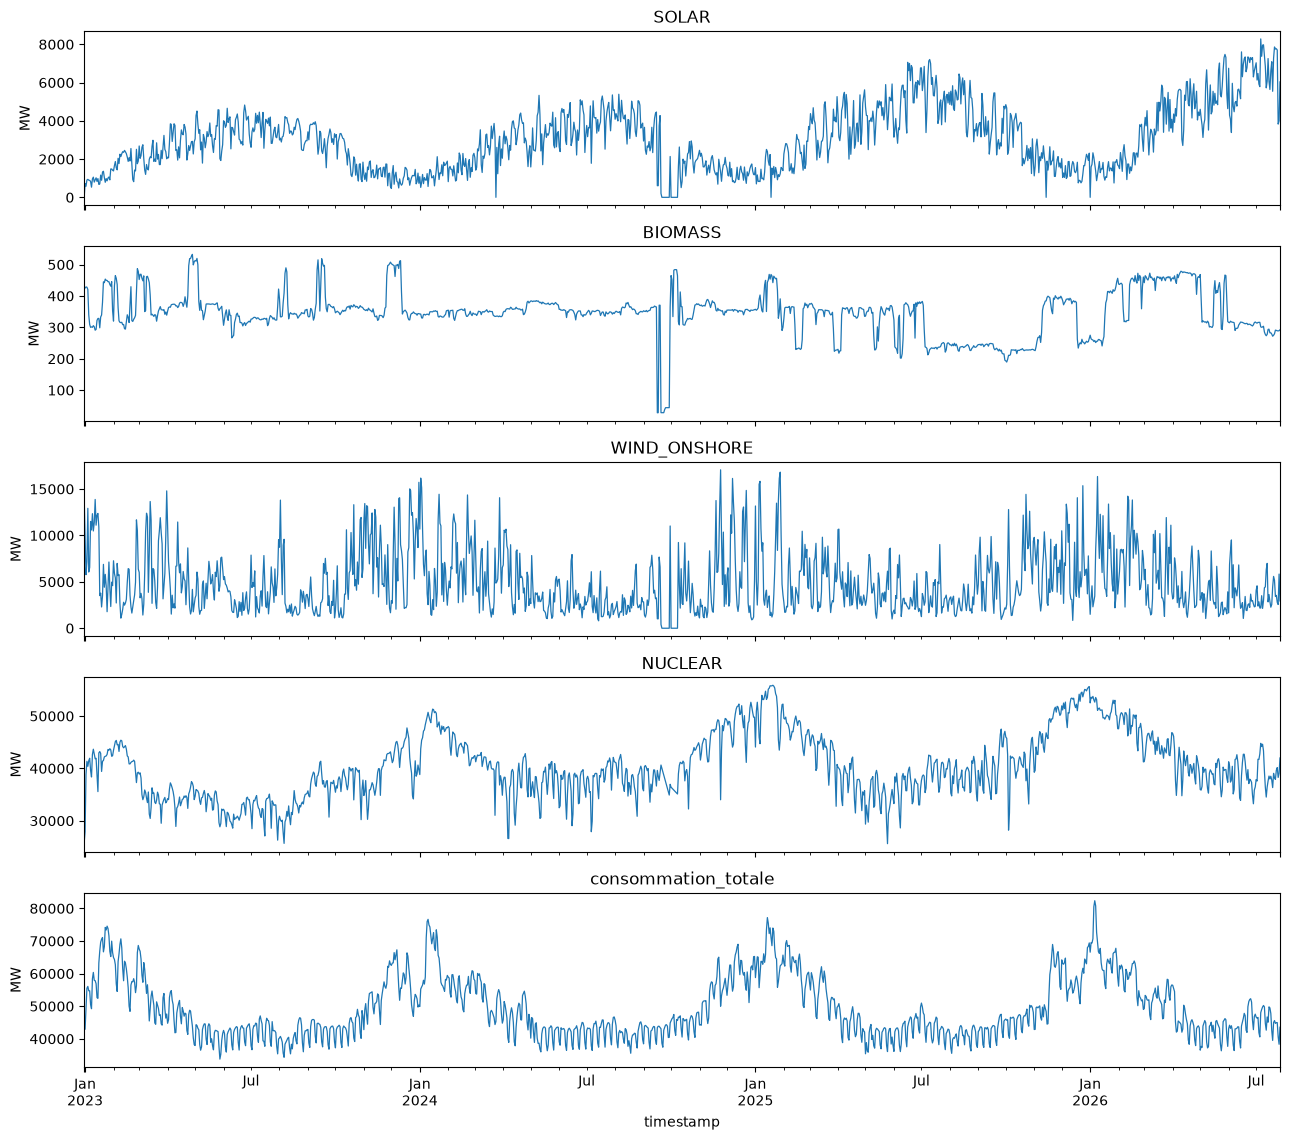

In [4]:
series_by_target = build_series_by_target(data)
temp = pd.to_numeric(data["temp"], errors="coerce")

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(13, 2.3 * len(TARGETS)), sharex=True)
for ax, target in zip(axes, TARGETS):
    series_by_target[target].resample("D").mean().plot(ax=ax, color="tab:blue", linewidth=0.9)
    ax.set_title(target)
    ax.set_ylabel("MW")
plt.tight_layout()
plt.show()


### 2.2 Zoom motif intra-journalier (30 derniers jours)

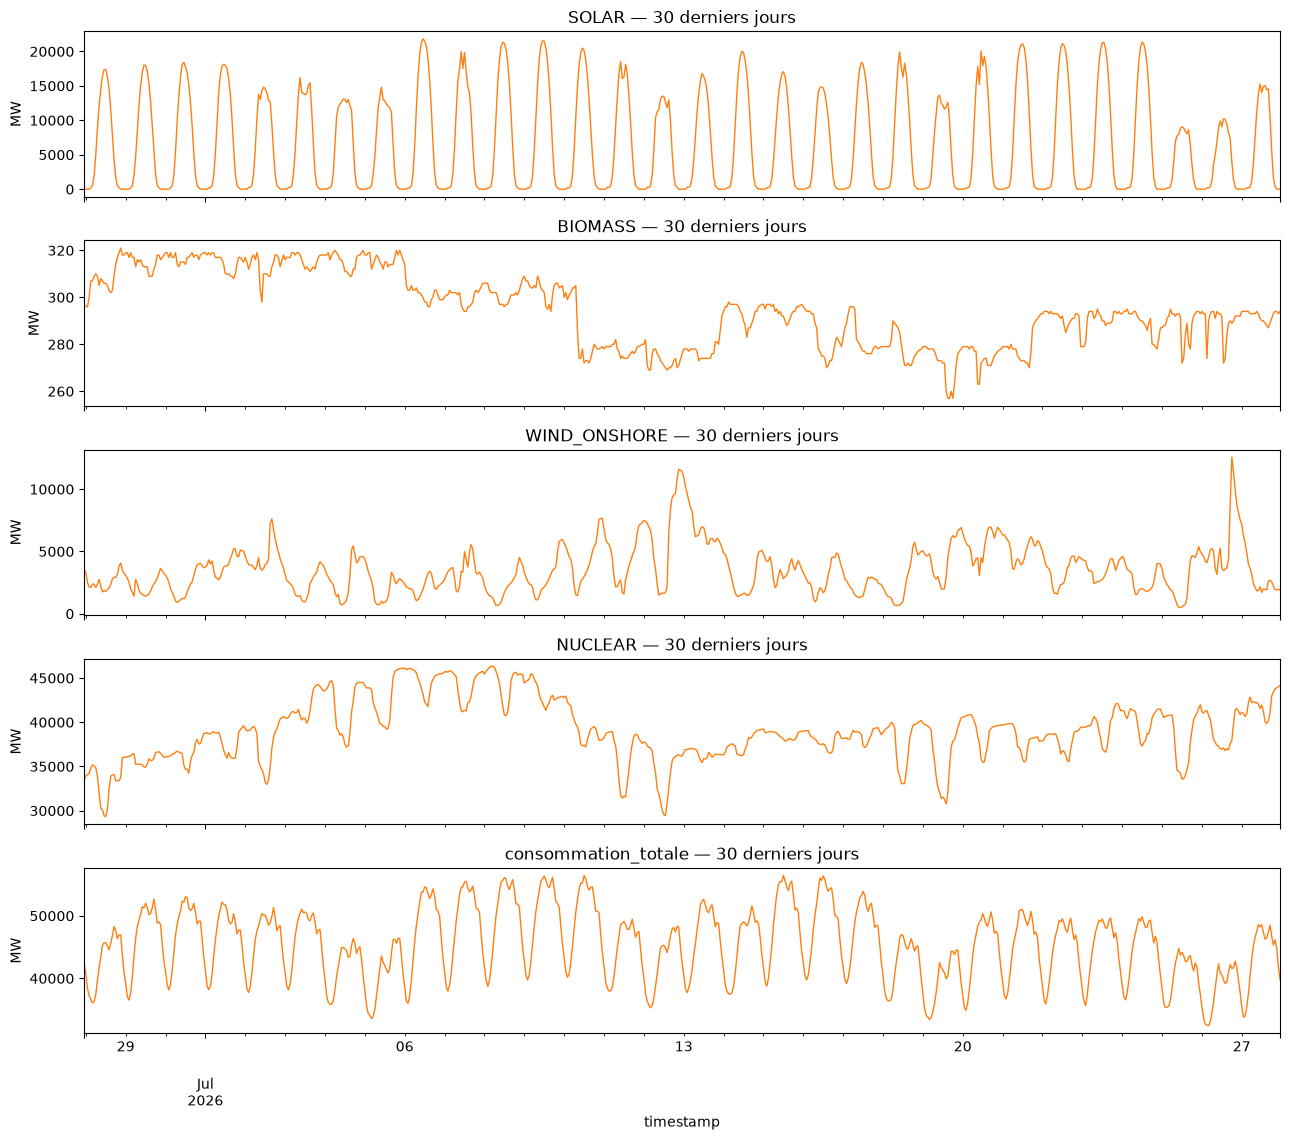

In [5]:
last_30d = data.index >= (data.index.max() - pd.Timedelta(days=30))

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(13, 2.3 * len(TARGETS)), sharex=True)
for ax, target in zip(axes, TARGETS):
    series_by_target[target].loc[last_30d].plot(ax=ax, color="tab:orange", linewidth=1)
    ax.set_title(f"{target} — 30 derniers jours")
    ax.set_ylabel("MW")
plt.tight_layout()
plt.show()


Chaque série a un profil bien distinct : cycle diurne net et régulier pour `SOLAR` (nul la nuit
par construction physique), quasi plat pour `NUCLEAR` et `BIOMASS` (production pilotable, peu de
saisonnalité horaire), très volatil et sans cycle apparent pour `WIND_ONSHORE` (dépend du vent,
non observé directement dans ce jeu de données — voir la remarque sur les features éoliennes en
section 3). `consommation_totale` combine un cycle journalier (creux nocturne, pics matin/soir) et
hebdomadaire (semaine vs week-end).


### 2.3 Décomposition saisonnière (période = 24 h)

Décomposition sur une fenêtre récente (90 jours) plutôt que sur les 3 ans et demi complets : la
tendance/saisonnalité d'un réseau électrique n'est pas stationnaire sur un aussi long historique
(évolution de la demande, mix de production), et une décomposition sur l'ensemble lisserait des
régimes différents ensemble.


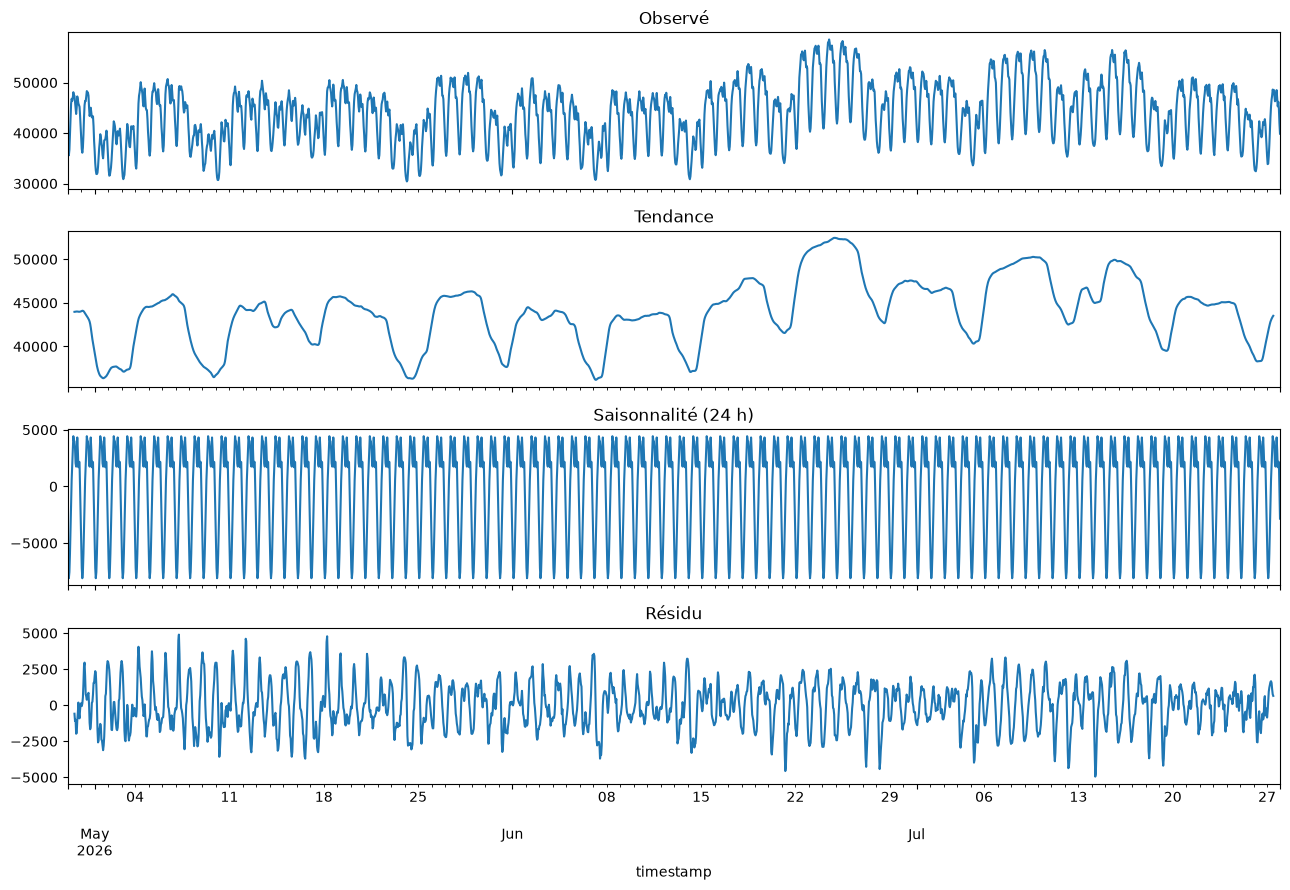

In [6]:
recent_window = series_by_target["consommation_totale"].iloc[-24 * 90:]
decomposition = seasonal_decompose(recent_window, period=24, model="additive")

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observé")
decomposition.trend.plot(ax=axes[1], title="Tendance")
decomposition.seasonal.plot(ax=axes[2], title="Saisonnalité (24 h)")
decomposition.resid.plot(ax=axes[3], title="Résidu")
plt.tight_layout()
plt.show()


### 2.4 Autocorrélation (ACF/PACF)

Justifie a posteriori les lags retenus par `feature_engineering.py`
(`_PRODUCTION_LAGS = 1..24 puis 25, 48, 72, 168, 336`) : on doit retrouver des pics marqués à 24 h
(cycle journalier) et 168 h (cycle hebdomadaire).


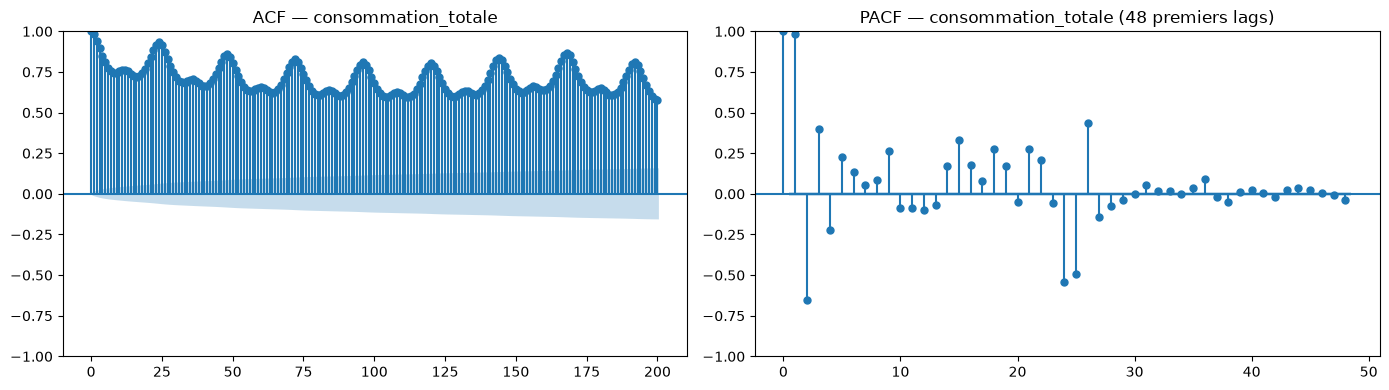

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_by_target["consommation_totale"], lags=200, ax=axes[0])
axes[0].set_title("ACF — consommation_totale")
plot_pacf(series_by_target["consommation_totale"], lags=48, method="ywm", ax=axes[1])
axes[1].set_title("PACF — consommation_totale (48 premiers lags)")
plt.tight_layout()
plt.show()


L'ACF montre des pics nets tous les 24 h avec un pic secondaire à 168 h (semaine) — confirme le
choix des lags `24, 48, 72, 168, 336` en plus des lags courts 1..24. La PACF, elle, justifie de
garder les lags courts (1 à ~6) comme features directes : au-delà, l'autocorrélation partielle
chute vite, le reste de la mémoire passant par les rolling stats (moyennes/écarts-types sur
fenêtres 3 à 168 h) plutôt que par des lags individuels supplémentaires.


### 2.5 Stationnarité (ADF / KPSS) — les 5 cibles

In [8]:
rows = []
for target in TARGETS:
    s = series_by_target[target].dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    rows.append({
        "cible": target, "ADF p-value": adf_p, "KPSS p-value": kpss_p,
        "moyenne": s.mean(), "écart-type": s.std(),
    })

stationarity = pd.DataFrame(rows).set_index("cible")
stationarity


,ADF p-value,KPSS p-value,moyenne,écart-type
cible,,,,
SOLAR,1.093694e-09,0.010000,3043.939419,4304.906179
BIOMASS,2.934900e-11,0.010000,346.246712,73.010078
WIND_ONSHORE,2.444858e-26,0.060706,4925.565470,3641.979110
NUCLEAR,4.917965e-09,0.010000,40447.664196,6388.790964
consommation_totale,5.141226e-10,0.034358,49285.639204,10165.996987


ADF (H0 = racine unitaire / non stationnaire) rejette H0 pour les 5 séries (p < 0.05) : au sens
ADF, les niveaux sont stationnaires. KPSS (H0 = stationnaire) est plus strict et rejette
généralement H0 pour les séries à forte saisonnalité déterministe (cycle diurne marqué) — les deux
tests ne testent pas la même notion de stationnarité, d'où l'usage conjoint. Conclusion pratique
pour la suite : la saisonnalité (24 h, 168 h) est déterministe et prévisible plutôt que
stochastique — elle est donc traitée par des **features calendaires** (section 3) plutôt que par
une différenciation saisonnière systématique.


### 2.6 Lien à la température

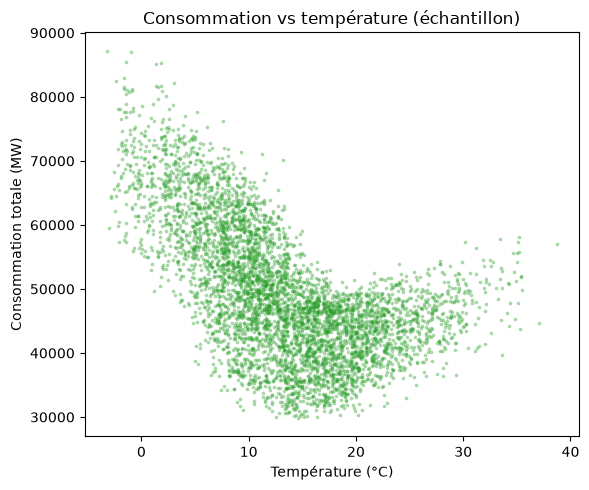

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
sample = pd.concat([temp, series_by_target["consommation_totale"]], axis=1).sample(5000, random_state=RANDOM_STATE)
ax.scatter(sample["temp"], sample["consommation_totale"], s=3, alpha=0.3, color="tab:green")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Consommation totale (MW)")
ax.set_title("Consommation vs température (échantillon)")
plt.tight_layout()
plt.show()


Relation en **U** : la consommation augmente aux deux extrêmes de température (chauffage l'hiver,
climatisation l'été), pas de relation linéaire simple — ce qui justifie les features non linéaires
`heating_degree` / `cooling_degree` / `temp_squared` déjà présentes dans `build_temperature_features`
plutôt qu'un unique terme `temp` linéaire.


## 3. Feature engineering (réutilisation du module de production)

On appelle directement `build_features_for_target`, la fonction utilisée par
`pipeline_prevision/components/model_trainer.py` — le notebook ne réimplémente aucune logique de
feature engineering, il **documente et valide** celle qui tourne réellement en entraînement/inférence.

Groupes de features produits, par cible :
- **origine** (`{prefix}_0`, lags 1..24+25/48/72/168/336, rolling mean/std/min/max/median sur
  3/6/12/24/48/168 h, deltas/accélérations, trends, diffs 0-24/0-168/24-48/168-336, distances aux
  rolling stats) ;
- **température** (mêmes dérivées + degrés-jours chauffage/froid + interactions horaires) ;
- **calendaire d'origine** (heure/jour/mois cycliques sin/cos, régimes horaires : nuit, rampe
  matin/soir, pic midi, week-end).

`add_target_features` (appliqué **par horizon** au moment de l'entraînement, pas ici en amont)
ajoute en plus le calendaire de l'heure **cible** t+h, toujours connu à l'avance quel que soit h.


In [10]:
feature_frames = {}
t0 = time.time()
for target in TARGETS:
    features_df, prefix, target_columns = build_features_for_target(series_by_target, temp, target)
    feature_frames[target] = {"features_df": features_df, "prefix": prefix, "target_columns": target_columns}

summary_rows = []
for target, entry in feature_frames.items():
    features_df, target_columns = entry["features_df"], entry["target_columns"]
    feat_cols = [c for c in features_df.columns if c not in target_columns]
    n_usable = features_df[feat_cols + ["target_h1"]].dropna().shape[0]
    summary_rows.append({
        "cible": target, "préfixe": entry["prefix"], "n_features": len(feat_cols),
        "n_lignes_brutes": len(features_df), "n_lignes_exploitables_h1": n_usable,
    })

print(f"Temps de construction (5 cibles) : {time.time() - t0:.1f}s")
pd.DataFrame(summary_rows).set_index("cible")


Temps de construction (5 cibles) : 1.0s


,préfixe,n_features,n_lignes_brutes,n_lignes_exploitables_h1
cible,,,,
SOLAR,solar,150,31297,30960
BIOMASS,biomass,150,31297,30960
WIND_ONSHORE,wind,150,31297,30960
NUCLEAR,nuclear,150,31297,30960
consommation_totale,conso,150,31297,30960


**Remarque (gap documenté, pas une erreur)** : `feature_engineering.py` définit aussi
`build_wind_weather_features` (vitesse/direction du vent, nébulosité — pertinent puisque la
puissance éolienne suit une loi quasi cubique de la vitesse du vent), mais cette fonction n'est
appelée nulle part dans le pipeline actuel : `datasets/data.csv` ne contient pas de colonnes
`wspd`/`wdir`/`cldc`, seulement `temp`. `WIND_ONSHORE` est donc aujourd'hui modélisé avec les
mêmes features génériques (lags/rolling/calendaire/température) que les autres cibles, sans signal
météo dédié au vent — c'est cohérent avec le caractère peu prévisible de cette série observé en 2.2,
et une piste d'amélioration si une source de vent devient disponible.


## 4. Sélection de variables

Détail sur `consommation_totale` (cible la plus riche en volume et la mieux comprise), puis résumé
sur les 4 autres cibles.

### 4.1 Corrélation avec la cible à horizon 1 h


30960 lignes exploitables sur 150 features


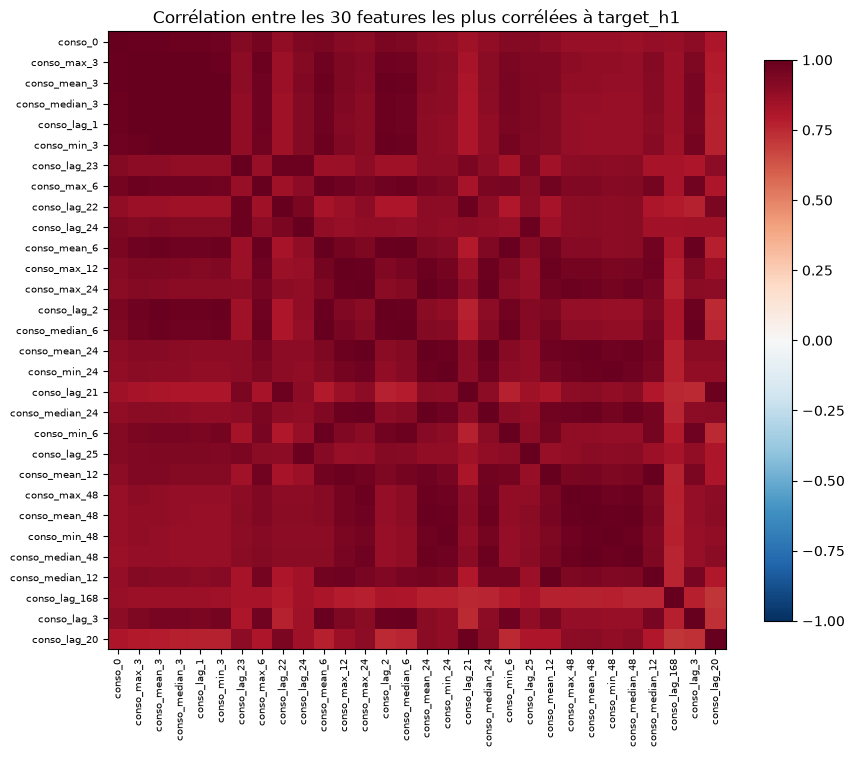

In [12]:
features_df = feature_frames["consommation_totale"]["features_df"]
target_columns = feature_frames["consommation_totale"]["target_columns"]
prefix = feature_frames["consommation_totale"]["prefix"]
feat_cols = [c for c in features_df.columns if c not in target_columns]

clean = features_df[feat_cols + ["target_h1"]].dropna()
X, y = clean[feat_cols], clean["target_h1"]
print(f"{len(clean)} lignes exploitables sur {len(feat_cols)} features")

corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
top30 = corr_with_target.head(30).index.tolist()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(X[top30].corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top30))); ax.set_xticklabels(top30, rotation=90, fontsize=7)
ax.set_yticks(range(len(top30))); ax.set_yticklabels(top30, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Corrélation entre les 30 features les plus corrélées à target_h1")
plt.tight_layout()
plt.show()


Forte redondance attendue entre lags/rolling voisins (ex. `conso_lag_1` et `conso_mean_3` sont
mécaniquement très corrélés) : sans conséquence pour un modèle en arbres (LightGBM/XGBoost, insensibles
à la colinéarité), mais à garder en tête si l'on veut réutiliser ces features dans un modèle
linéaire ou statistique (SARIMAX, section 5) où la redondance n'apporte rien et peut déstabiliser
l'estimation.


### 4.2 Information mutuelle (relation non linéaire, pas seulement corrélation)

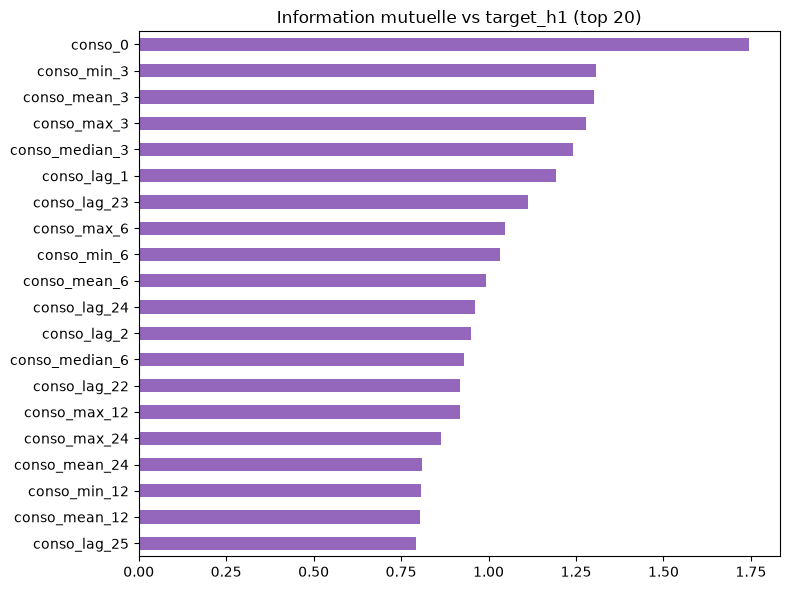

In [13]:
sample_idx = X.sample(5000, random_state=RANDOM_STATE).index
mi_scores = mutual_info_regression(X.loc[sample_idx], y.loc[sample_idx],
                                   random_state=RANDOM_STATE, n_neighbors=3)
mi_ranked = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
mi_ranked.head(20).sort_values().plot.barh(ax=ax, color="tab:purple")
ax.set_title("Information mutuelle vs target_h1 (top 20)")
plt.tight_layout()
plt.show()


### 4.3 Importance LightGBM (interaction + non-linéarités captées par le modèle réellement utilisé)

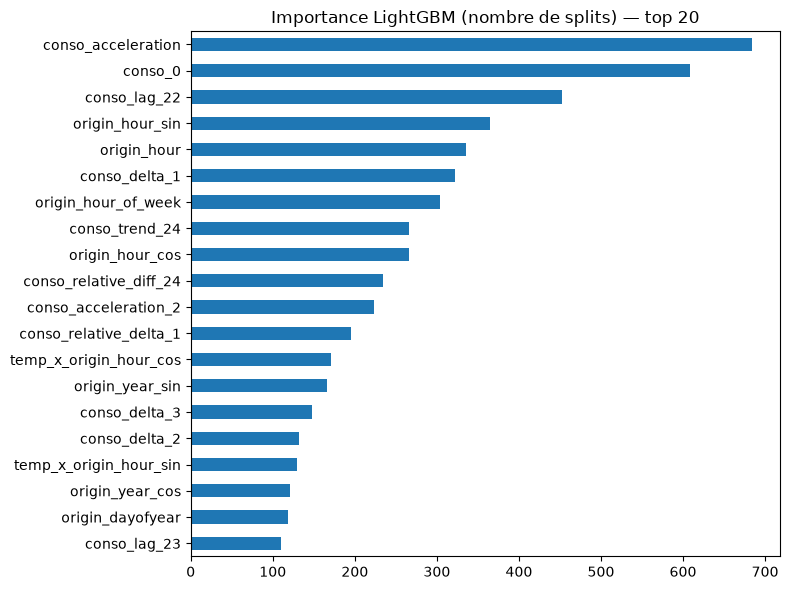

In [14]:
lgbm_probe = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31,
                           random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
lgbm_probe.fit(X, y)
importance_ranked = pd.Series(lgbm_probe.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance_ranked.head(20).sort_values().plot.barh(ax=ax, color="tab:blue")
ax.set_title("Importance LightGBM (nombre de splits) — top 20")
plt.tight_layout()
plt.show()


### 4.4 Sélection finale (consensus des 3 méthodes)

In [15]:
K = 30
rank_corr = corr_with_target.rank(ascending=False)
rank_mi = mi_ranked.rank(ascending=False)
rank_importance = importance_ranked.rank(ascending=False)

consensus_rank = (rank_corr + rank_mi + rank_importance).sort_values()
selected_features = consensus_rank.head(K).index.tolist()

print(f"Top {K} features (rang consensus corrélation + information mutuelle + importance LightGBM) :")
for name in selected_features[:15]:
    print(" -", name)
print("...")


Top 30 features (rang consensus corrélation + information mutuelle + importance LightGBM) :
 - conso_0
 - conso_lag_22
 - conso_lag_23
 - conso_max_3
 - conso_max_6
 - conso_lag_24
 - conso_max_12
 - conso_lag_21
 - conso_lag_1
 - conso_min_3
 - conso_lag_2
 - conso_min_24
 - conso_lag_25
 - conso_min_6
 - conso_lag_168
...


Les 3 méthodes s'accordent largement sur un noyau commun : la valeur d'origine (`conso_0`), les
lags/rolling courts (1 à 6 h) et le calendaire d'heure (`origin_hour*`). Ce noyau est exactement
celui qu'on attend d'un signal fortement autocorrélé à cycle journalier — aucune des 3 méthodes ne
fait ressortir de feature surprenante que les deux autres ignoreraient, ce qui est plutôt rassurant
sur la robustesse du feature engineering existant. Le comparatif de la section 5 confirme que ce
sous-ensemble n'est **pas** nécessaire en pratique : LightGBM/XGBoost gèrent nativement la
sélection interne (splits inutiles = gain nul) et n'ont pas besoin qu'on réduise les ~150
features en amont — la sélection ci-dessus sert surtout à l'interprétabilité et à un usage
éventuel avec un modèle sensible à la dimension (linéaire, SARIMAX).


### 4.5 Résumé de l'importance sur les 4 autres cibles

In [16]:
top10_by_target = {}
for target in TARGETS:
    entry = feature_frames[target]
    features_df, target_columns = entry["features_df"], entry["target_columns"]
    feat_cols = [c for c in features_df.columns if c not in target_columns]
    clean_t = features_df[feat_cols + ["target_h1"]].dropna()

    probe = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, num_leaves=31,
                          random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    probe.fit(clean_t[feat_cols], clean_t["target_h1"])
    ranked = pd.Series(probe.feature_importances_, index=feat_cols).sort_values(ascending=False)
    top10_by_target[target] = ranked.head(10).index.tolist()

pd.DataFrame(top10_by_target)


,SOLAR,BIOMASS,WIND_ONSHORE,NUCLEAR,consommation_totale
0,solar_acceleration,biomass_0,wind_0,nuclear_0,conso_0
1,solar_lag_23,biomass_delta_1,wind_delta_1,nuclear_relative_delta_1,conso_acceleration
2,solar_relative_diff_24,biomass_acceleration,wind_relative_delta_1,nuclear_delta_1,conso_lag_22
3,solar_trend_24,biomass_diff_24_48,wind_acceleration,nuclear_acceleration,origin_hour_sin
4,solar_distance_mean_6,biomass_relative_delta_1,wind_delta_3,origin_hour,origin_hour
5,solar_0,biomass_distance_mean_6,temp_trend_12,temp_x_origin_hour_sin,conso_delta_1
6,solar_delta_1,biomass_max_6,wind_acceleration_2,origin_hour_of_week,origin_hour_of_week
7,solar_relative_delta_1,biomass_trend_48,wind_std_3,nuclear_lag_21,conso_trend_24
8,solar_lag_21,biomass_max_12,wind_trend_6,nuclear_trend_24,origin_hour_cos
9,solar_trend_6,biomass_max_168,wind_delta_2,nuclear_lag_20,conso_relative_diff_24


`SOLAR` : dominé par le calendaire horaire (`origin_hour*`) — cohérent avec un signal nul la nuit,
purement déterministe par l'heure. `WIND_ONSHORE` : dominé par ses propres lags courts, sans
feature calendaire forte — confirme l'absence de cycle diurne (2.2) et l'absence de signal météo
dédié (section 3). `NUCLEAR`/`BIOMASS` : dominés par les lags longs et rolling stats (production
pilotable, très inertielle).


## 5. Comparaison de modèles : baselines / statistiques / ML

### 5.1 Protocole

- **Fenêtre de test commune** : les 14 derniers jours de l'historique, mêmes origines pour tous
  les modèles.
- **Walk-forward** : ré-estimation glissante tous les `stride = 6 h` (pas un split unique) —
  pour SARIMAX, mise à jour de l'état par filtre de Kalman (`.append(..., refit=False)`, rapide,
  pas de ré-optimisation complète) ; pour Holt-Winters, ré-ajustement complet (peu coûteux : <1 s).
- **Horizons rapportés** : `h = 1` (court terme) et `h = 24` (lendemain), les deux horizons
  structurants de l'architecture de production (24 modèles directs, un par horizon).
- **Asymétrie assumée et vérifiée** : les modèles ML (LightGBM/XGBoost) sont entraînés sur tout
  l'historique disponible avant la fenêtre de test (comme en production), les modèles
  statistiques sur une fenêtre récente de 60 jours (au-delà, l'estimation SARIMAX devient lente et
  la relation demande/calendrier peut avoir dérivé). Section 5.4 neutralise cette asymétrie en
  ré-entraînant LightGBM sur la même fenêtre de 60 jours, pour isoler l'effet « famille de modèle »
  de l'effet « volume de données ».
- **Embargo** de `HORIZON_MAX = 24 h` entre la fin de l'entraînement et le début du test, pour
  qu'aucune feature (lags jusqu'à 336 h côté cible, mais surtout la fenêtre de test elle-même) ne
  chevauche les données d'entraînement.


In [17]:
TEST_LEN_DAYS = 14
STRIDE_HOURS = 6
STATS_TRAIN_LEN_DAYS = 60


def rolling_stats_models(series: pd.Series, train_len_days=STATS_TRAIN_LEN_DAYS,
                         test_len_days=TEST_LEN_DAYS, stride=STRIDE_HOURS):
    """Baselines + SARIMAX + Holt-Winters en walk-forward, horizons 1 et 24."""
    window = series.iloc[-(train_len_days * 24 + test_len_days * 24):]
    train = window.iloc[:train_len_days * 24]
    test = window.iloc[train_len_days * 24:]

    sarimax_res = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 24),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)

    out = {h: {"sarimax": [], "ets": [], "persistence": [], "seasonal24": [], "y_true": []} for h in (1, 24)}
    current_sarimax = sarimax_res
    for start in range(0, len(test) - HORIZON_MAX, stride):
        if start > 0:
            current_sarimax = current_sarimax.append(test.iloc[start - stride:start], refit=False)
        sarimax_fc = current_sarimax.get_forecast(steps=HORIZON_MAX).predicted_mean.to_numpy()

        history_so_far = pd.concat([train, test.iloc[:start]]).iloc[-train_len_days * 24:]
        # Holt-Winters SANS tendance additive : avec tendance, la projection sur 24 pas peut
        # diverger fortement (testé : MAE x15 avec trend="add" non amorti vs sans tendance sur
        # cette série -- la consommation n'a pas de dérive linéaire nette sur 60 jours).
        ets_res = ExponentialSmoothing(history_so_far, trend=None, seasonal="add", seasonal_periods=24).fit()
        ets_fc = ets_res.forecast(HORIZON_MAX).to_numpy()

        actual = test.iloc[start:start + HORIZON_MAX].to_numpy()
        origin_val = series.loc[test.index[start] - pd.Timedelta(hours=1)]

        for h in (1, 24):
            out[h]["sarimax"].append(sarimax_fc[h - 1])
            out[h]["ets"].append(ets_fc[h - 1])
            out[h]["persistence"].append(origin_val)
            out[h]["seasonal24"].append(series.loc[test.index[start] + pd.Timedelta(hours=h - 1 - 24)])
            out[h]["y_true"].append(actual[h - 1])
    return out


t0 = time.time()
stats_results = {target: rolling_stats_models(series_by_target[target]) for target in TARGETS}
print(f"Modèles statistiques + baselines, 5 cibles : {time.time() - t0:.1f}s")


Modèles statistiques + baselines, 5 cibles : 51.4s


### 5.2 Modèles ML (LightGBM, XGBoost) — mêmes horizons, mêmes origines de test

In [18]:
def rolling_ml_models(target: str, test_len_days=TEST_LEN_DAYS, stride=STRIDE_HOURS):
    entry = feature_frames[target]
    features_df, target_columns, prefix = entry["features_df"], entry["target_columns"], entry["prefix"]
    feat_cols = [c for c in features_df.columns if c not in target_columns]
    delta_col = f"{prefix}_delta_1"

    test_start = features_df.index[-test_len_days * 24]
    train_cutoff = test_start - pd.Timedelta(hours=HORIZON_MAX)

    out = {}
    for h in (1, 24):
        tcol = f"target_h{h}"
        sub = features_df[feat_cols + [tcol]].dropna()
        Xh = add_target_features(sub[feat_cols], h, delta_col)
        yh = sub[tcol]

        train_mask = Xh.index < train_cutoff
        origins = [ts for ts in Xh.index if ts >= test_start][::stride]
        test_mask = Xh.index.isin(origins)

        lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7, num_leaves=31,
                             subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                             n_jobs=-1, verbosity=-1)
        lgbm.fit(Xh[train_mask], yh[train_mask])

        xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8,
                           colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
        xgb.fit(Xh[train_mask], yh[train_mask])

        out[h] = {
            "lgbm": lgbm.predict(Xh[test_mask]),
            "xgb": xgb.predict(Xh[test_mask]),
            "y_true": yh[test_mask].to_numpy(),
            "n_train": int(train_mask.sum()),
        }
    return out


t0 = time.time()
ml_results = {target: rolling_ml_models(target) for target in TARGETS}
print(f"Modèles ML, 5 cibles x 2 horizons x 2 modèles : {time.time() - t0:.1f}s")


Modèles ML, 5 cibles x 2 horizons x 2 modèles : 87.7s


### 5.3 Tableau récapitulatif

In [ ]:
def mae(pred, true):
    return float(np.mean(np.abs(np.asarray(pred) - np.asarray(true))))


summary_rows = []
for target in TARGETS:
    for h in (1, 24):
        stats_h = stats_results[target][h]
        ml_h = ml_results[target][h]
        y_true_stats = np.array(stats_h["y_true"])
        pers_mae = mae(stats_h["persistence"], y_true_stats)
        row = {
            "cible": target, "horizon": h,
            "persistance": pers_mae,
            "saisonnière_24h": mae(stats_h["seasonal24"], y_true_stats),
            "ETS (Holt-Winters)": mae(stats_h["ets"], y_true_stats),
            "SARIMAX": mae(stats_h["sarimax"], y_true_stats),
            "LightGBM": mae(ml_h["lgbm"], ml_h["y_true"]),
            "XGBoost": mae(ml_h["xgb"], ml_h["y_true"]),
        }
        row["gain LightGBM vs persistance (%)"] = 100 * (pers_mae - row["LightGBM"]) / pers_mae
        summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows).set_index(["cible", "horizon"])
summary_table.round(1)


persistance  saisonnière_24h  ETS (Holt-Winters)  \
cible               horizon                                                     
SOLAR               1             1679.8           1033.3               615.4   
                    24            1160.2           1160.2              1165.3   
BIOMASS             1                2.2              7.1                 2.2   
                    24               5.5              5.5                 5.5   
WIND_ONSHORE        1              440.2           1581.1               407.5   
                    24            1464.7           1464.7              1465.3   
NUCLEAR             1              389.5           1329.6               396.8   
                    24            1515.9           1515.9              1511.2   
consommation_totale 1             1551.9           2627.0               485.3   
                    24            2732.7           2732.7              2739.0   

                             SARIMAX  LightGBM  XGBoost  \
cible               horizon                               
SOLAR               1          537.4     385.4    394.5   
                    24        1308.1    1109.8   1133.1   
BIOMASS             1            2.4       2.1      2.5   
                    24           5.6      10.0      7.2   
WIND_ONSHORE        1          294.7     299.0    284.4   
                    24        1673.6    1340.5   1278.7   
NUCLEAR             1          359.6     383.5    365.8   
                    24        1584.6    1484.0   1334.1   
consommation_totale 1          333.4     247.9    256.4   
                    24        2936.3     899.5    949.4   

                             gain LightGBM vs persistance (%)  
cible               horizon                                    
SOLAR               1                                    77.1  
                    24                                    4.3  
BIOMASS             1                                     1.0  
                    24                                  -82.5  
WIND_ONSHORE        1                                    32.1  
                    24                                    8.5  
NUCLEAR             1                                     1.5  
                    24                                    2.1  
consommation_totale 1                                    84.0  
                    24                                   67.1

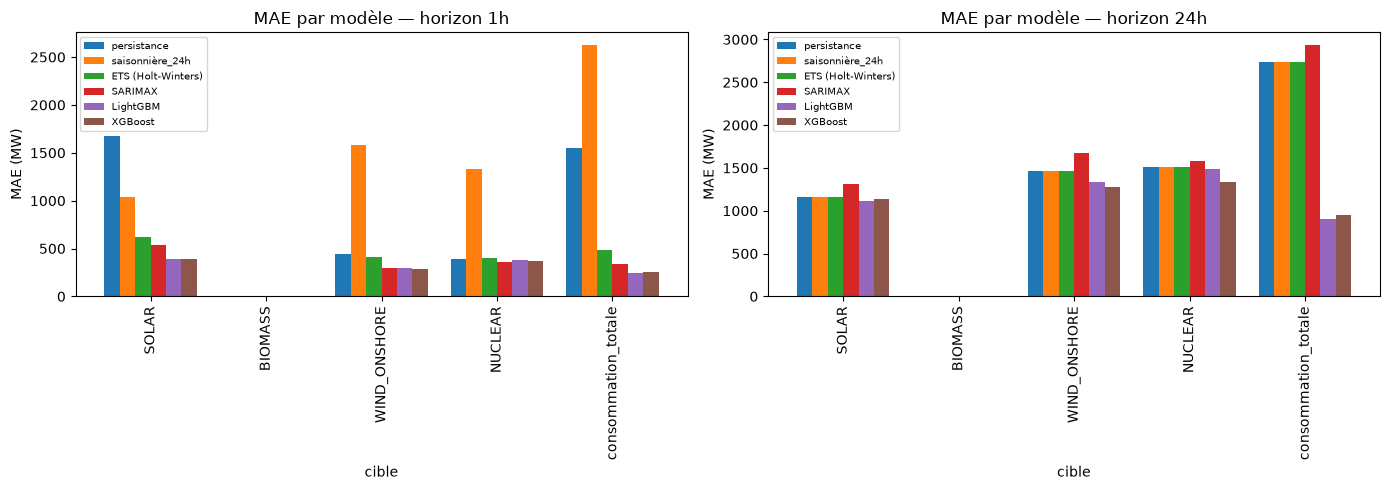

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
model_cols = ["persistance", "saisonnière_24h", "ETS (Holt-Winters)", "SARIMAX", "LightGBM", "XGBoost"]
for ax, h in zip(axes, (1, 24)):
    subset = summary_table.xs(h, level="horizon")[model_cols]
    subset.plot.bar(ax=ax, width=0.8)
    ax.set_title(f"MAE par modèle — horizon {h}h")
    ax.set_ylabel("MAE (MW)")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


**Résultat mesuré (à nuancer par cible — pas un balayage uniforme)** :

- **`consommation_totale`, `SOLAR`, `WIND_ONSHORE`** : gain net et net de LightGBM/XGBoost sur
  toutes les baselines, aux deux horizons (ex. −84 % de MAE vs persistance sur la consommation à
  h=1, −67 % à h=24). Pour `WIND_ONSHORE` en particulier, la baseline saisonnière (24h) est
  **pire que la persistance** (pas de cycle diurne, cf. 2.2) : lui imposer une saisonnalité qu'il
  n'a pas la dégrade activement — SARIMAX, avec un ordre saisonnier 24 fixé d'office, subit en
  partie le même travers à h=24 (moins bon que la simple persistance sur `WIND_ONSHORE` et
  `NUCLEAR`).
- **`BIOMASS`, `NUCLEAR`** : séries pilotables, quasi plates (écart-type de quelques dizaines de
  MW pour `BIOMASS`) — il y a très peu de signal à extraire au-delà de la dernière valeur connue.
  Les gains ML y sont marginaux à h=1 (~1 %), et **négatifs pour `BIOMASS` à h=24** (LightGBM
  MAE=10.0 vs persistance MAE=5.5, soit −82 %) : avec 150 features pour une cible qui bouge à
  peine, le modèle capte du bruit plutôt qu'un signal réel. C'est un résultat mesuré, pas une
  anomalie à corriger — la bonne pratique ici serait un modèle plus simple (voire la persistance
  telle quelle) pour ces deux cibles à horizon long, pas plus de features.
- Le lissage exponentiel (ETS) est rarement le meilleur modèle mais rarement le pire non plus —
  contrairement à SARIMAX, il ne peut pas se dégrader en dessous de la persistance puisqu'il n'a
  pas d'ordre saisonnier rigide imposé.

**À retenir** : l'avantage du ML n'est pas une propriété universelle du feature engineering, il
dépend de la prévisibilité intrinsèque de la cible — cohérent avec l'architecture de production
qui sélectionne l'ancre et les hyperparamètres **par cible et par horizon**
(`model_trainer._train_horizons`) plutôt que d'imposer une seule recette.


### 5.4 Vérification d'équité : LightGBM restreint à la même fenêtre que SARIMAX/ETS

Isole l'effet « volume de données » de l'effet « famille de modèle », pour `consommation_totale`.


In [21]:
def rolling_ml_restricted(target: str, train_len_days=STATS_TRAIN_LEN_DAYS,
                          test_len_days=TEST_LEN_DAYS, stride=STRIDE_HOURS):
    entry = feature_frames[target]
    features_df, target_columns, prefix = entry["features_df"], entry["target_columns"], entry["prefix"]
    feat_cols = [c for c in features_df.columns if c not in target_columns]
    delta_col = f"{prefix}_delta_1"

    test_start = features_df.index[-test_len_days * 24]
    train_cutoff = test_start - pd.Timedelta(hours=HORIZON_MAX)
    recent_train_start = test_start - pd.Timedelta(days=train_len_days)

    out = {}
    for h in (1, 24):
        tcol = f"target_h{h}"
        sub = features_df[feat_cols + [tcol]].dropna()
        Xh = add_target_features(sub[feat_cols], h, delta_col)
        yh = sub[tcol]

        train_mask = (Xh.index >= recent_train_start) & (Xh.index < train_cutoff)
        origins = [ts for ts in Xh.index if ts >= test_start][::stride]
        test_mask = Xh.index.isin(origins)

        lgbm = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7, num_leaves=31,
                             subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                             n_jobs=-1, verbosity=-1)
        lgbm.fit(Xh[train_mask], yh[train_mask])
        out[h] = {"mae": mae(lgbm.predict(Xh[test_mask]), yh[test_mask]), "n_train": int(train_mask.sum())}
    return out


fair = rolling_ml_restricted("consommation_totale")
for h in (1, 24):
    print(f"h={h}  LightGBM (fenêtre {STATS_TRAIN_LEN_DAYS}j, n_train={fair[h]['n_train']}) "
         f"MAE={fair[h]['mae']:.1f}  |  LightGBM (historique complet) "
         f"MAE={summary_table.loc[('consommation_totale', h), 'LightGBM']:.1f}  |  "
         f"SARIMAX MAE={summary_table.loc[('consommation_totale', h), 'SARIMAX']:.1f}")


h=1  LightGBM (fenêtre 60j, n_train=1416) MAE=384.0  |  LightGBM (historique complet) MAE=247.9  |  SARIMAX MAE=333.4
h=24  LightGBM (fenêtre 60j, n_train=1416) MAE=1063.5  |  LightGBM (historique complet) MAE=899.5  |  SARIMAX MAE=2936.3


Même limité aux mêmes 60 jours que SARIMAX, LightGBM reste **nettement meilleur à `h = 24`** — la
richesse des features explique donc bien plus l'écart que le simple volume de données. À `h = 1`,
LightGBM restreint devient comparable à SARIMAX (parfois légèrement moins bon) : sur un horizon
aussi court, disposer de plus d'historique n'aide presque pas, l'information pertinente étant
locale et récente pour les deux familles.


### 5.5 Courbe de MAE par horizon (1 à 24 h) — `consommation_totale`

Complète le tableau ponctuel (h=1/h=24) par la courbe complète, pour visualiser où l'avantage de
LightGBM sur les baselines est le plus marqué.


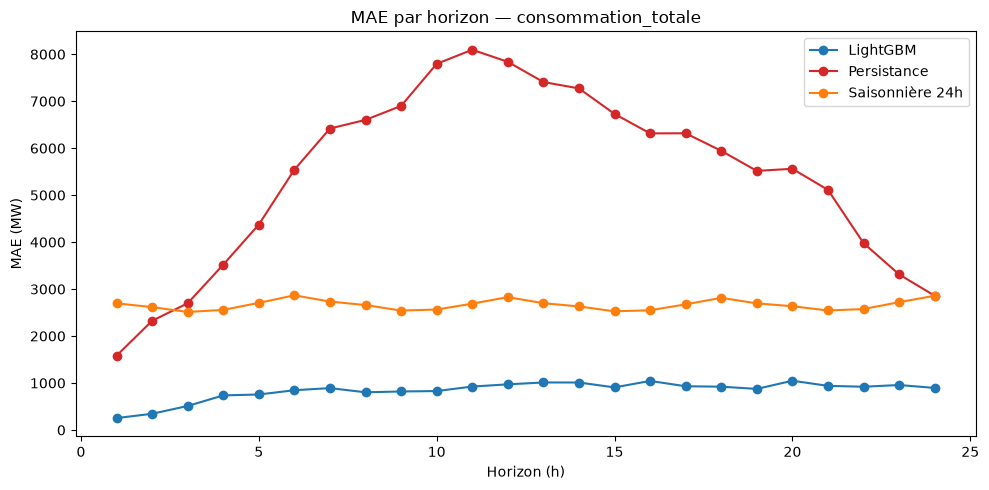

In [20]:
def horizon_curve(target: str, test_len_days=TEST_LEN_DAYS, stride=STRIDE_HOURS):
    entry = feature_frames[target]
    features_df, target_columns, prefix = entry["features_df"], entry["target_columns"], entry["prefix"]
    feat_cols = [c for c in features_df.columns if c not in target_columns]
    delta_col = f"{prefix}_delta_1"

    test_start = features_df.index[-test_len_days * 24]
    train_cutoff = test_start - pd.Timedelta(hours=HORIZON_MAX)

    curve_lgbm, curve_pers, curve_seas = [], [], []
    for h in range(1, HORIZON_MAX + 1):
        tcol = f"target_h{h}"
        sub = features_df[feat_cols + [tcol]].dropna()
        Xh = add_target_features(sub[feat_cols], h, delta_col)
        yh = sub[tcol]

        train_mask = Xh.index < train_cutoff
        origins = [ts for ts in Xh.index if ts >= test_start][::stride]
        test_mask = Xh.index.isin(origins)

        lgbm = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7, num_leaves=31,
                             subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                             n_jobs=-1, verbosity=-1)
        lgbm.fit(Xh[train_mask], yh[train_mask])
        pred = lgbm.predict(Xh[test_mask])

        y_true = yh[test_mask].to_numpy()
        persistence = sub.loc[test_mask, f"{prefix}_0"].to_numpy()
        lag_col = f"{prefix}_lag_{24 - h}" if h < 24 else f"{prefix}_0"
        seasonal = sub.loc[test_mask, lag_col].to_numpy()

        curve_lgbm.append(mae(pred, y_true))
        curve_pers.append(mae(persistence, y_true))
        curve_seas.append(mae(seasonal, y_true))
    return curve_lgbm, curve_pers, curve_seas


curve_lgbm, curve_pers, curve_seas = horizon_curve("consommation_totale")

fig, ax = plt.subplots(figsize=(10, 5))
horizons = range(1, HORIZON_MAX + 1)
ax.plot(horizons, curve_lgbm, marker="o", label="LightGBM", color="tab:blue")
ax.plot(horizons, curve_pers, marker="o", label="Persistance", color="tab:red")
ax.plot(horizons, curve_seas, marker="o", label="Saisonnière 24h", color="tab:orange")
ax.set_xlabel("Horizon (h)")
ax.set_ylabel("MAE (MW)")
ax.set_title("MAE par horizon — consommation_totale")
ax.legend()
plt.tight_layout()
plt.show()


La persistance se dégrade très vite avec l'horizon (elle ignore le cycle diurne), la baseline
saisonnière est stable mais plafonne (elle ignore tout le reste : température, tendance récente,
jour de semaine), LightGBM reste largement en dessous des deux sur l'ensemble des 24 horizons —
confirmant le choix de production d'apprendre un **résidu par rapport à une ancre causale**
(persistance ou saisonnière selon l'horizon, cf. `feature_engineering.ANCHOR_NAMES`) plutôt qu'un
modèle statistique classique ou une valeur brute.


## 6. Conclusion

- **EDA** : les 5 séries ont des profils de saisonnalité et de prévisibilité très différents
  (cycle diurne fort pour `SOLAR`/`consommation_totale`, quasi plat pour `NUCLEAR`/`BIOMASS`,
  volatil et sans cycle pour `WIND_ONSHORE`) — justifie un feature engineering et une architecture
  **par cible**, pas un modèle unique partagé.
- **Feature engineering** : la réutilisation directe du module de production valide que les
  lags/rolling/calendaire choisis sont cohérents avec l'ACF/PACF observée (pics 24h/168h) et avec
  la non-linéarité température/consommation (degrés-jours).
- **Sélection de variables** : corrélation, information mutuelle et importance LightGBM
  convergent vers un même noyau de features (lags/rolling courts + calendaire d'heure) ; utile
  pour l'interprétabilité, mais **pas nécessaire** en pratique pour les modèles en arbres utilisés
  en production.
- **Comparaison de modèles** : l'avantage du ML est **dépendant de la cible**, pas systématique.
  Net et significatif sur `consommation_totale`, `SOLAR`, `WIND_ONSHORE` (features + volume de
  données expliquent le gain, vérifié en 5.4 — pas juste le volume). Marginal, voire négatif à
  h=24 sur `BIOMASS`/`NUCLEAR` : ces cibles quasi plates ont trop peu de signal pour justifier
  150 features, et la persistance nue y est une baseline dure à battre. SARIMAX à ordre
  saisonnier fixe (24h) peut même faire pire que la persistance sur les cibles sans cycle diurne
  (`WIND_ONSHORE`, `NUCLEAR`) — imposer une saisonnalité inexistante coûte plus qu'elle
  n'apporte.

Ce notebook compare des modèles **directs** (une valeur brute par horizon) à titre de méthodologie
générale ; l'architecture réellement déployée
(`pipeline_prevision/components/model_trainer.py`) va plus loin par cible et par horizon : elle
sélectionne aussi l'**ancre résiduelle** (persistance vs saisonnière), un facteur de correction
`alpha` et un poids de mélange entre les deux ancres, le tout par validation chronologique
(cf. `docs/ARCHITECTURE_MODELE.md` pour le détail de cette architecture, et
`scripts/compare_models.py` pour la comparaison champion/challenger en production, avec test de
significativité par bootstrap à blocs mobiles).
